In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)



In [30]:
df = pd.read_csv('../data/raw/loan_applications.csv')

# df.head(10)
display(df.describe())

df.info()

,age,employment_years,annual_income,credit_score,loan_amount,loan_term_months,existing_debt,num_open_accounts,num_late_payments,dti_ratio,origination_year,fed_funds_rate,interest_rate_offered
count,5030.000000,5030.000000,4725.000000,4625.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000,5030.000000
mean,37.810736,4.842843,55111.764789,351.928649,46029.483101,51.089463,20062.536873,4.018091,0.794632,0.292499,2021.995427,2.248670,4.585878
std,9.437235,4.743611,40699.705991,41.443923,36622.062338,25.071105,21909.990304,2.002948,1.228583,0.589165,0.816768,2.061794,3.183467
min,22.000000,0.000000,1993.230000,300.000000,5000.000000,12.000000,613.470000,0.000000,0.000000,0.000500,2021.000000,-0.400000,2.500000
25%,31.000000,1.400000,28629.700000,315.000000,22700.000000,36.000000,7437.802500,3.000000,0.000000,0.037125,2021.000000,0.177000,2.500000
50%,38.000000,3.400000,45524.820000,348.000000,35900.000000,48.000000,13546.255000,4.000000,0.000000,0.089550,2022.000000,1.681000,3.095000
75%,44.000000,6.700000,70522.690000,380.000000,57675.000000,60.000000,24331.072500,5.000000,1.000000,0.236425,2023.000000,4.916750,5.653250
max,70.000000,40.000000,720319.790000,542.000000,426200.000000,120.000000,300000.000000,13.000000,5.000000,4.903568,2023.000000,5.531000,28.000000


<class 'pandas.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   borrower_id            5030 non-null   str    
 1   age                    5030 non-null   int64  
 2   employment_type        5030 non-null   str    
 3   employment_years       5030 non-null   float64
 4   annual_income          4725 non-null   float64
 5   credit_score           4625 non-null   float64
 6   loan_amount            5030 non-null   float64
 7   loan_term_months       5030 non-null   int64  
 8   loan_purpose           5030 non-null   str    
 9   existing_debt          5030 non-null   float64
 10  num_open_accounts      5030 non-null   int64  
 11  num_late_payments      5030 non-null   int64  
 12  dti_ratio              5030 non-null   float64
 13  origination_date       5030 non-null   str    
 14  origination_year       5030 non-null   int64  
 15  origination_qua

# Handle Missing Values
- there are missing vals in annual income and credit score, later ill explore this if it has a pattern
- will decide later for impute or dropping


In [ ]:
missing_vals = df.isnull().sum()
missing_percent = ((missing_vals / len(df)) * 100).round(2)



missing_df = pd.DataFrame({'Missing_Count': missing_vals, 'Percentage(%)': missing_percent})
missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage(%)', ascending=False)

,Missing_Count,Percentage(%)
credit_score,405,8.05
annual_income,305,6.06


# Duplicates
- checked for duplicates and tried looking at it if its just the name or some columns are duplicated
- turns out all the duplicated rows are same in across all the cols
- decided to drop it

In [43]:
df_copy = df.copy()

duplicates = df_copy[df_copy.duplicated(keep=False)]
# display(duplicates.sort_values(by=df_copy.columns.tolist()))

id_duplicates = df[df.duplicated(subset=['borrower_id'], keep=False)]
# display(id_duplicates.sort_values(by='borrower_id'))

df_copy = df_copy.drop_duplicates()

# Univariate Analysis
- Check for relation and distribution of numerical and categorical vals
- check for outliers

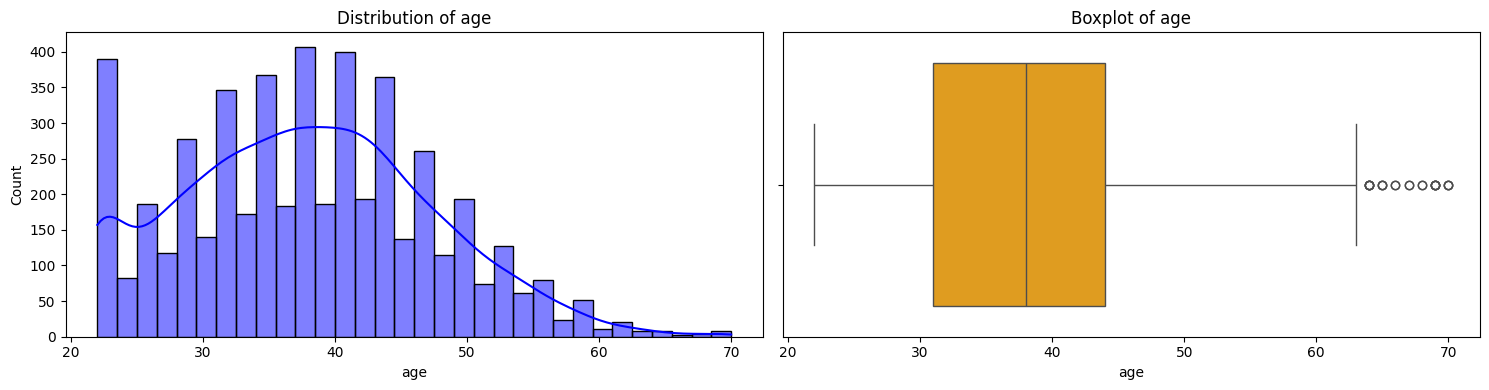

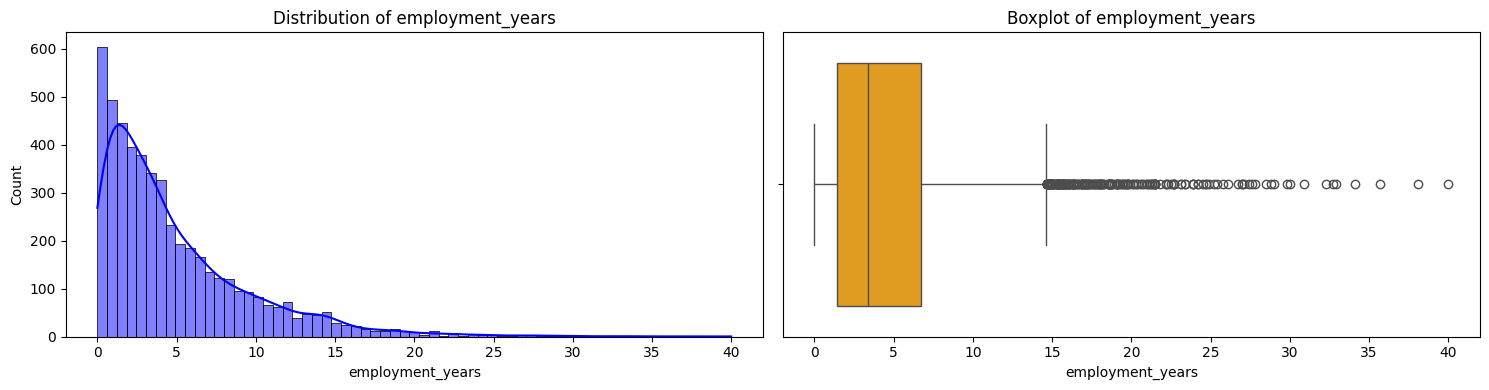

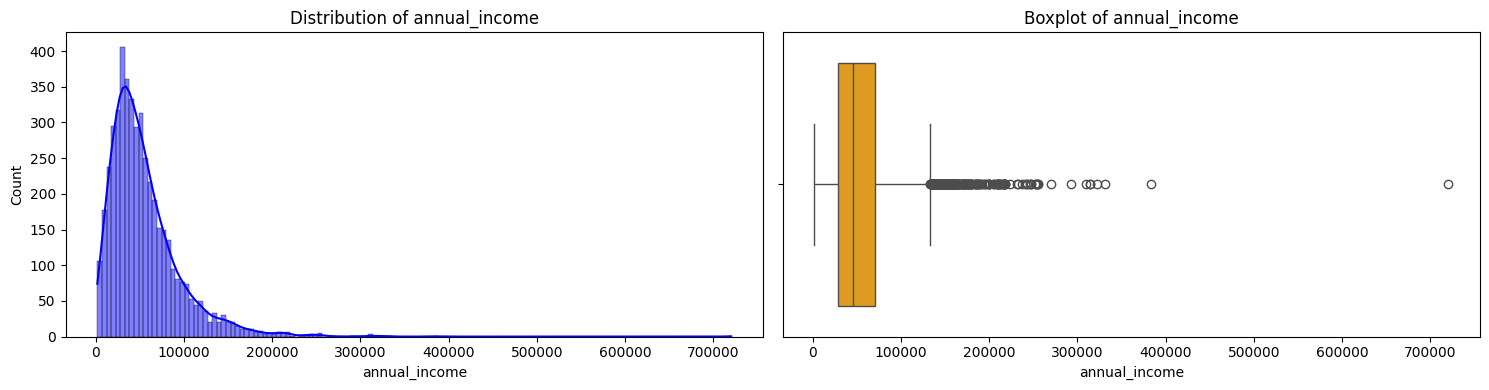

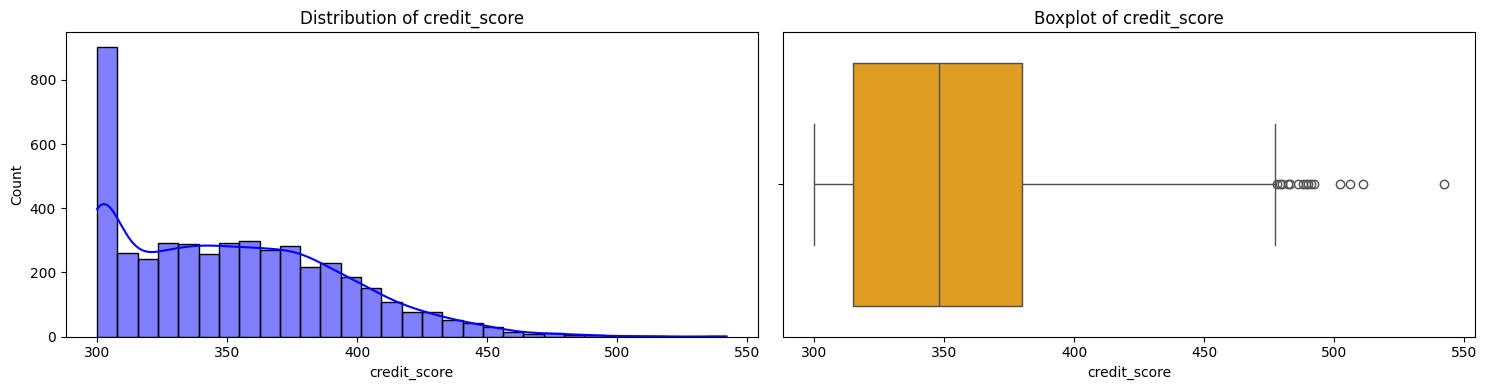

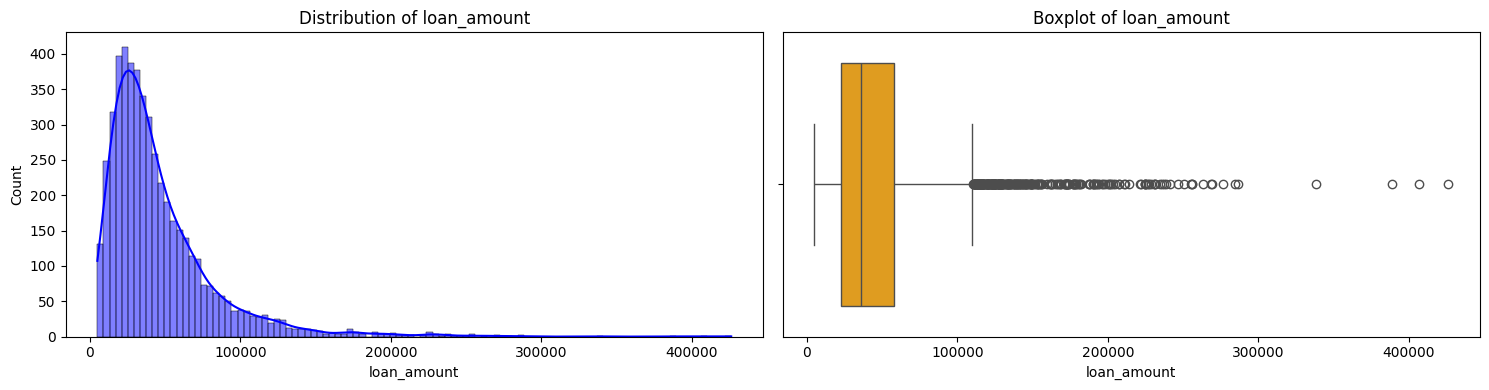

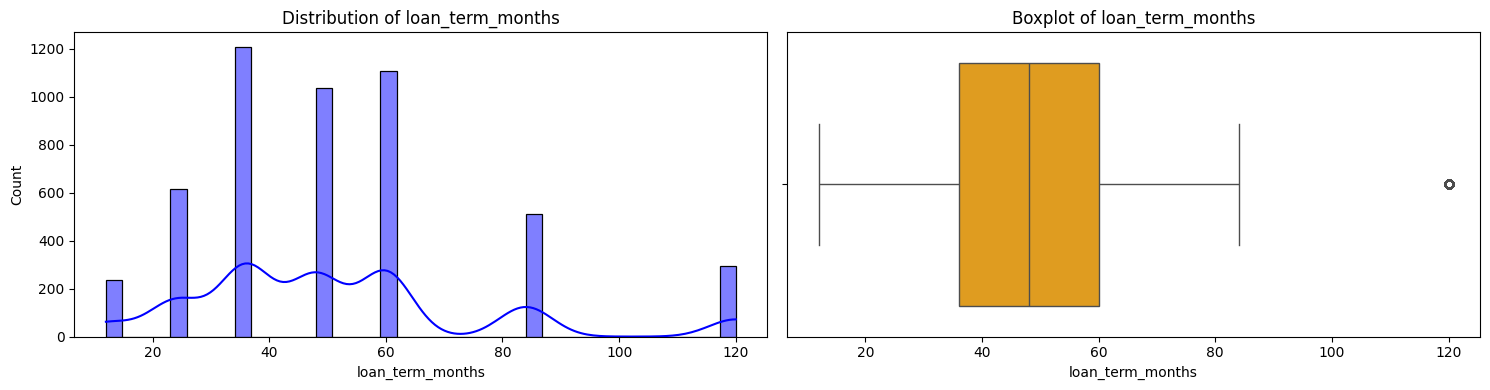

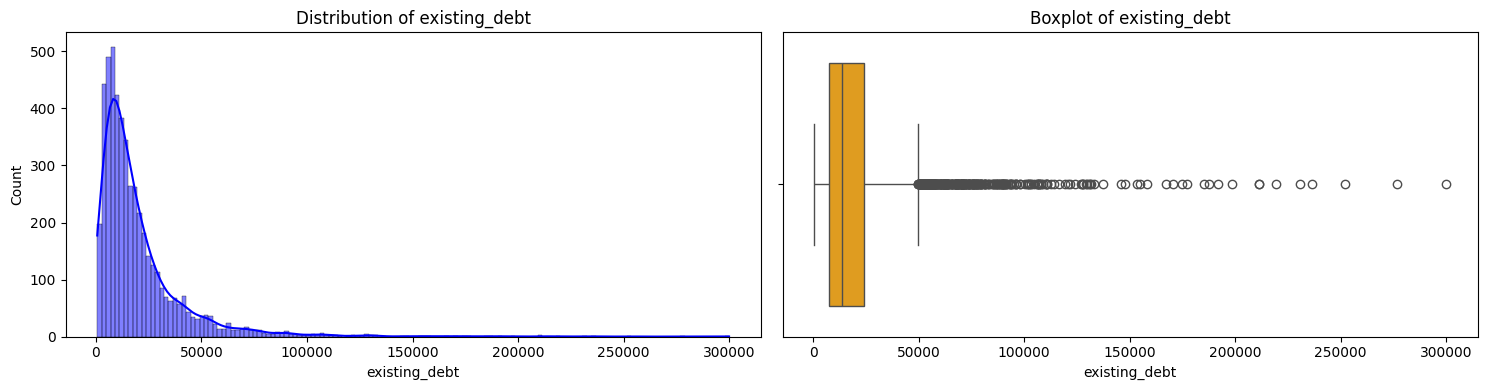

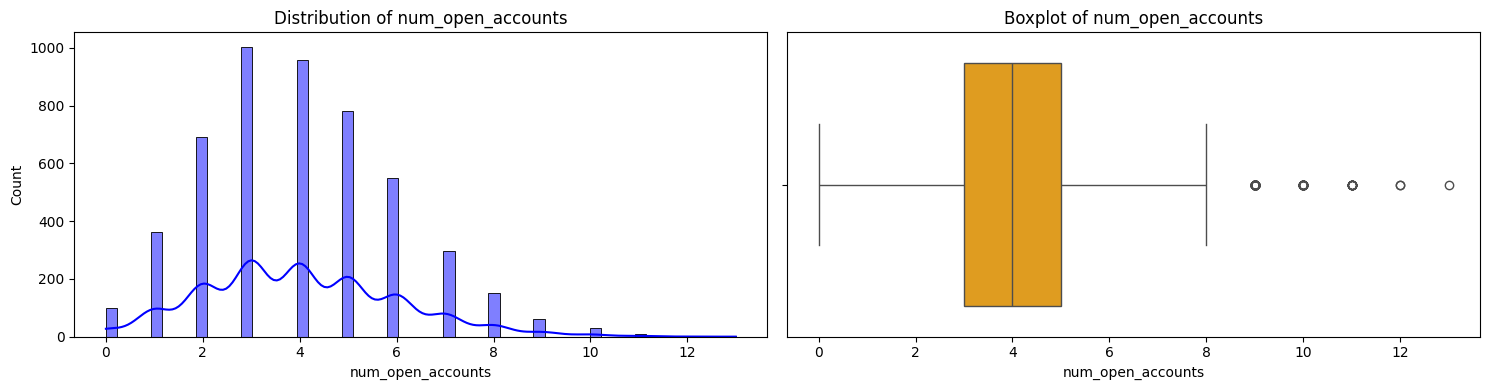

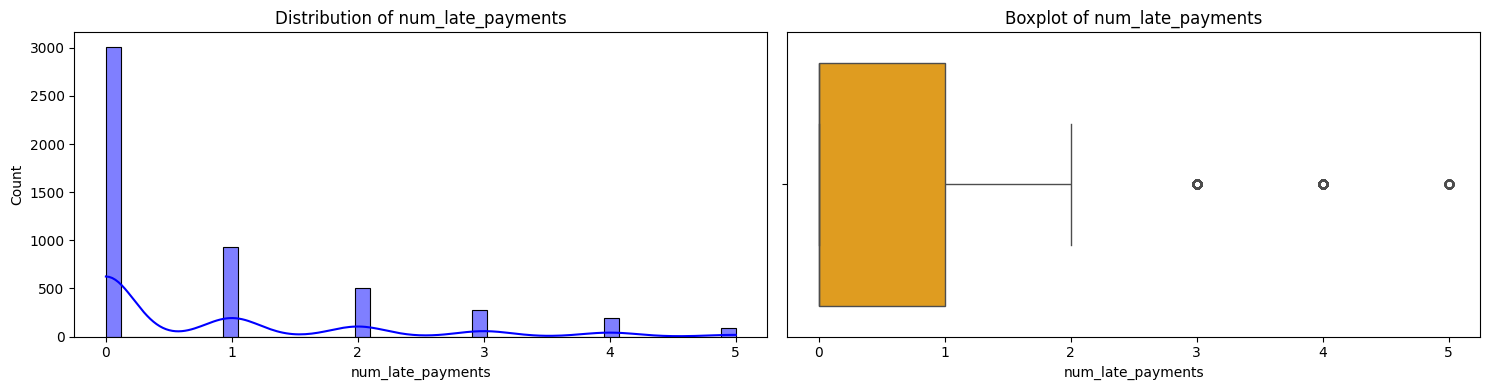

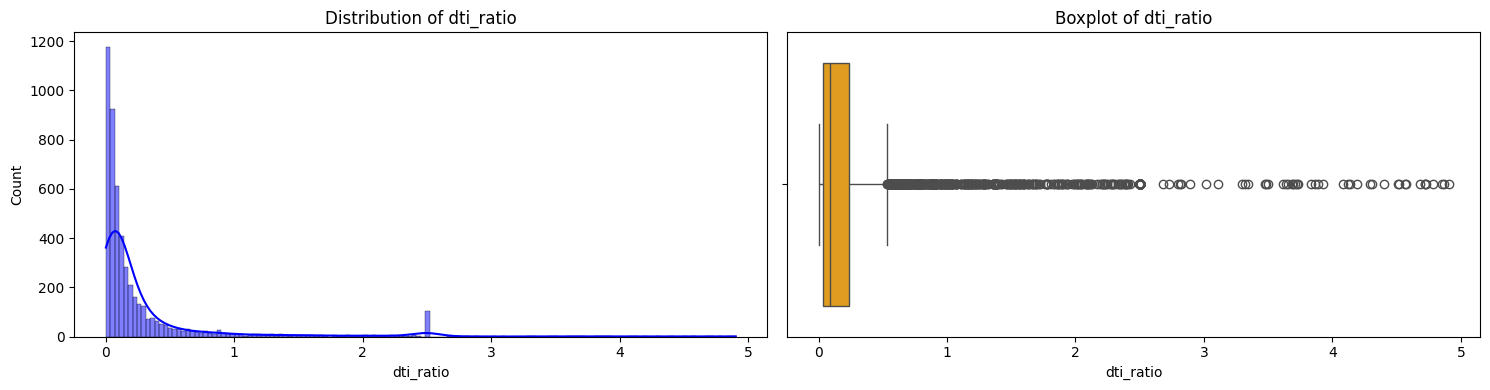

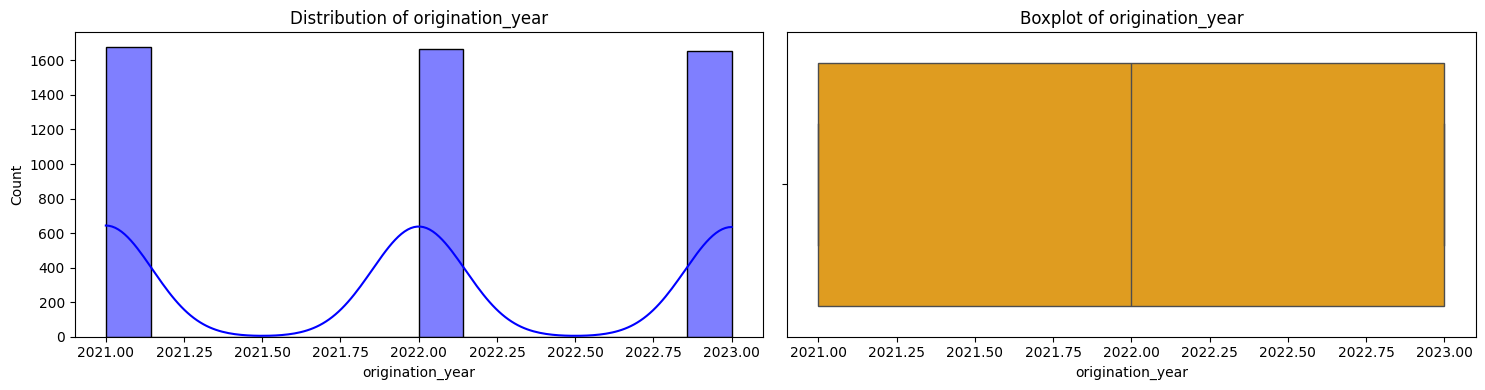

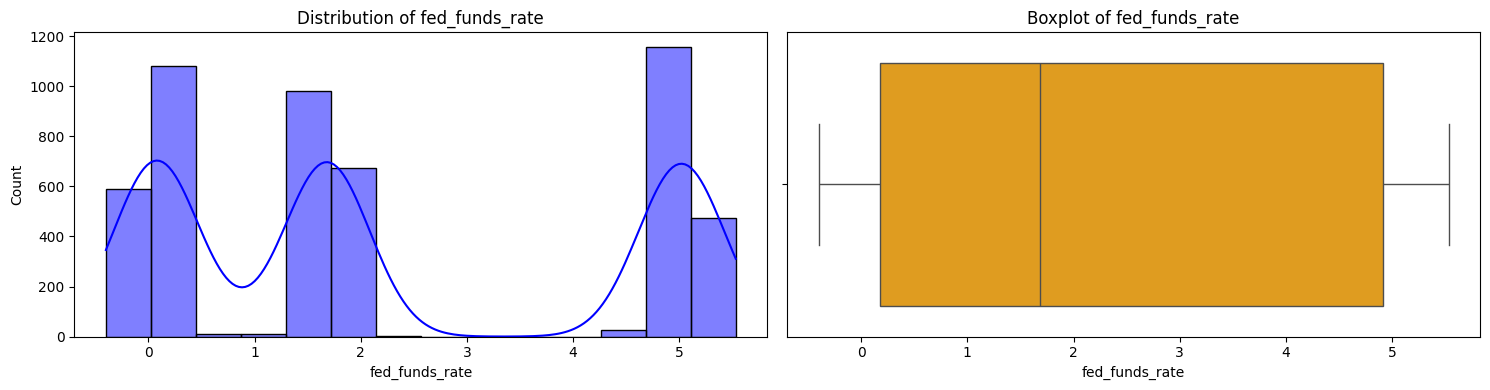

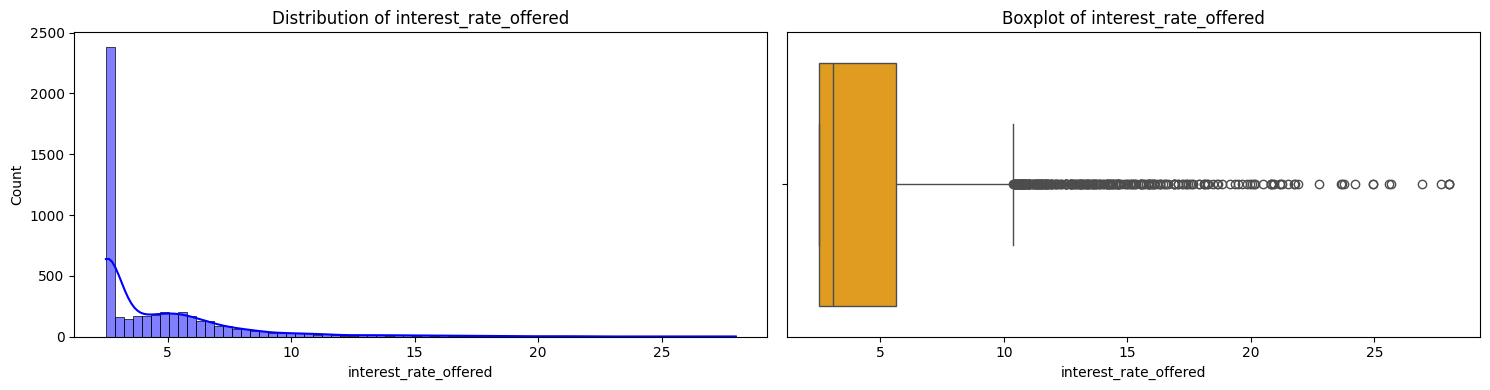

In [60]:
# df.info()
num_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_copy.select_dtypes(include=['str']).columns.tolist()

cat_cols.remove('borrower_id')
cat_cols.remove('origination_date')

# print(f"Numerical columns: {num_cols}")
# print(f"Categorical columns: {cat_cols}")

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(15,4))

    sns.histplot(df_copy[col], kde=True, ax=ax[0], color='blue')
    ax[0].set_title(f"Distribution of {col}")
    
    sns.boxplot(x=df_copy[col], ax=ax[1], color='orange')
    ax[1].set_title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{col}_distribution.png')
    plt.show()
    
